# Vehicle Sales Database Ingestion & SQL Analytics Pipeline
This notebook contains the complete logic converted from the Vehicle Sales Database Application. It handles data loading, strict cleaning and validation, bulk database ingestion, and runs analytics queries directly on XAMPP MySQL on port `33007`.

### Pipeline Steps:
1. **Environment Setup & Imports**: Load required standard libraries (`mysql.connector`, `csv`, `datetime`, `tabulate`).
2. **Database Setup**: Connect to XAMPP MySQL on port `33007` and build the database schema.
3. **Data Cleaning**: Implement standard Python parsing rules (without pandas/numpy) to clean data rows.
4. **Data Ingestion**: Bulk insert sorted cleaned records into the MySQL database.
5. **Data Quality Checks**: Verify schema types, duplicates, and missing values using SQL.
6. **Business Insights & SQL Reports**: Execute standard SQL queries for volume, profit, weekly, monthly, and transmission trends.

### Optional: Install tabulate and mysql-connector
If your environment is missing `mysql-connector-python` or `tabulate`, uncomment and run the following cell to install them:

In [1]:
#!pip install mysql-connector-python tabulate

## 1. Connection & Configuration Setup
We load connection parameters from the `.env` file or fall back to the default port `33007` for XAMPP. Then we test the connection to ensure the MySQL service is reachable.

In [2]:
import os
import sys
import csv
import datetime
import mysql.connector
from mysql.connector import Error
from tabulate import tabulate

# Database configuration
DB_HOST = "127.0.0.1"
DB_PORT = 33007
DB_USER = "root"
DB_PASSWORD = ""
DB_NAME = "vehicle_sales_db"
CSV_FILE_PATH = os.path.join("data", "car_prices.csv")
MAX_ROWS = 50000  # Target records to ingest

print(f"[*] Connecting to database service on {DB_HOST}:{DB_PORT}...")

# Test Connection
try:
    conn = mysql.connector.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USER,
        password=DB_PASSWORD
    )
    if conn.is_connected():
        print(f"[+] Success: Connected to MySQL service at {DB_HOST}:{DB_PORT}")
        conn.close()
except Error as e:
    print(f"[-] Connection failed: {e}")
    print("[!] Please make sure XAMPP MySQL is running on port 33007.")

[*] Connecting to database service on 127.0.0.1:33007...
[+] Success: Connected to MySQL service at 127.0.0.1:33007


## 2. Create Database and Table Schema
We check and create the `vehicle_sales_db` database and the `car_sales` table with proper datatypes and indices.

In [3]:
def setup_database():
    try:
        conn = mysql.connector.connect(
            host=DB_HOST,
            port=DB_PORT,
            user=DB_USER,
            password=DB_PASSWORD
        )
        cursor = conn.cursor()
        
        # Create DB
        cursor.execute(f"CREATE DATABASE IF NOT EXISTS {DB_NAME}")
        print(f"[+] Database '{DB_NAME}' checked/created successfully.")
        
        # Create Table
        cursor.execute(f"USE {DB_NAME}")
        create_table_query = """
        CREATE TABLE IF NOT EXISTS car_sales (
            id INT AUTO_INCREMENT PRIMARY KEY,
            year INT,
            make VARCHAR(50),
            model VARCHAR(100),
            trim VARCHAR(100),
            body VARCHAR(50),
            transmission VARCHAR(20),
            vin VARCHAR(50),
            state VARCHAR(10),
            `condition` FLOAT,
            odometer INT,
            color VARCHAR(50),
            interior VARCHAR(50),
            seller VARCHAR(255),
            mmr INT,
            sellingprice INT,
            saledate DATE,
            saleday VARCHAR(20),
            INDEX idx_vin (vin)
        ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
        """
        cursor.execute(create_table_query)
        print("[+] Table 'car_sales' checked/created successfully.")
        
        cursor.close()
        conn.close()
    except Error as e:
        print(f"[-] Schema setup failed: {e}")

setup_database()

[+] Database 'vehicle_sales_db' checked/created successfully.
[+] Table 'car_sales' checked/created successfully.


## 3. Date Parser & Data Cleaning Functions (Pure Python)
We implement the cleaning functions using only pure Python code and standard library modules (`csv`, `datetime`) to validate, clean, and cast data fields.

In [4]:
def parse_saledate(date_str):
    """
    Parses timezone-aware strings such as 'Tue Dec 16 2014 12:30:00 GMT-0800 (PST)'
    """
    if not date_str:
        return None
    date_str = date_str.strip()
    
    parts = date_str.split()
    if len(parts) >= 5:
        clean_str = f"{parts[1]} {parts[2]} {parts[3]} {parts[4]}"
        try:
            return datetime.datetime.strptime(clean_str, "%b %d %Y %H:%M:%S")
        except ValueError:
            pass
            
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d", "%m/%d/%Y %H:%M", "%m/%d/%Y"):
        try:
            return datetime.datetime.strptime(date_str, fmt)
        except ValueError:
            continue
            
    return None

def clean_row(row):
    """
    Validates and cleans a raw row dict. Returns the cleaned dict or None if invalid.
    """
    missing_placeholders = {'', '—', 'null', 'nan', 'none', 'n/a', 'na', '-', 'undefined'}
    
    # Check for missing placeholders
    for col, val in row.items():
        if val is None:
            return None
        val_str = str(val).strip()
        if not val_str or val_str.lower() in missing_placeholders:
            return None
            
    cleaned = {}
    
    # Year
    try:
        year_val = int(row['year'].strip())
        if year_val < 1900 or year_val > datetime.datetime.now().year + 2:
            return None
        cleaned['year'] = year_val
    except ValueError:
        return None
        
    # Strings
    cleaned['make'] = row['make'].strip().title()
    cleaned['model'] = row['model'].strip().title()
    cleaned['trim'] = row['trim'].strip()
    cleaned['body'] = row['body'].strip().title()
    
    # Transmission
    trans = row['transmission'].strip().lower()
    if 'auto' in trans:
        cleaned['transmission'] = 'automatic'
    elif 'man' in trans:
        cleaned['transmission'] = 'manual'
    else:
        return None
        
    # VIN
    vin = row['vin'].strip().upper()
    if len(vin) < 5 or not vin.isalnum():
        return None
    cleaned['vin'] = vin
    
    # State
    cleaned['state'] = row['state'].strip().upper()
    
    # Condition (0 to 50)
    try:
        cond = float(row['condition'].strip())
        if cond < 0 or cond > 50:
            return None
        cleaned['condition'] = cond
    except ValueError:
        return None
        
    # Odometer
    try:
        odo = int(row['odometer'].strip())
        if odo < 0:
            return None
        cleaned['odometer'] = odo
    except ValueError:
        return None
        
    # Color, Interior, Seller
    cleaned['color'] = row['color'].strip().title()
    cleaned['interior'] = row['interior'].strip().title()
    cleaned['seller'] = row['seller'].strip()
    
    # MMR
    try:
        mmr = int(row['mmr'].strip())
        if mmr < 0:
            return None
        cleaned['mmr'] = mmr
    except ValueError:
        return None
        
    # Selling Price
    try:
        sp = int(row['sellingprice'].strip())
        if sp < 0:
            return None
        cleaned['sellingprice'] = sp
    except ValueError:
        return None
        
    # Sale Date
    dt = parse_saledate(row['saledate'])
    if dt is None:
        return None
    cleaned['saledate_obj'] = dt
    cleaned['saledate'] = dt.strftime("%Y-%m-%d")
    cleaned['saleday'] = dt.strftime("%A")
    
    return cleaned

## 4. Bulk Data Ingestion Pipeline
We parse the CSV file, apply our cleaning rules, sort all records chronologically by their sale date, truncate the existing records, and bulk insert them into MySQL in batches of 5,000.

In [6]:
def run_ingestion():
    if not os.path.exists(CSV_FILE_PATH):
        print(f"[-] Error: CSV not found at {CSV_FILE_PATH}")
        return
        
    print(f"[1] Reading and cleaning CSV records (capping at {MAX_ROWS:,} valid records)...")
    cleaned_records = []
    total_scanned = 0
    total_skipped = 0
    
    with open(CSV_FILE_PATH, mode='r', encoding='utf-8', errors='ignore') as f:
        reader = csv.DictReader(f)
        for row in reader:
            total_scanned += 1
            cleaned = clean_row(row)
            if cleaned is not None:
                cleaned_records.append(cleaned)
                if len(cleaned_records) == MAX_ROWS:
                    print(f"[+] Collected target limit of {MAX_ROWS:,} cleaned records.")
                    break
            else:
                total_skipped += 1
                
    print(f"    - Total rows scanned: {total_scanned:,}")
    print(f"    - Cleaned rows collected: {len(cleaned_records):,}")
    print(f"    - Bad/missing rows skipped: {total_skipped:,}")
    
    if not cleaned_records:
        print("[-] No valid records found. Exiting.")
        return
        
    # Sort chronologically by date object
    print("\n[2] Sorting records chronologically by sale date...")
    cleaned_records.sort(key=lambda x: x['saledate_obj'])
    print(f"    - First record date: {cleaned_records[0]['saledate']}")
    print(f"    - Last record date: {cleaned_records[-1]['saledate']}")
    
    # Connect to MySQL and Insert
    print("\n[3] Connecting to MySQL on port 33007 to write data...")
    try:
        conn = mysql.connector.connect(
            host=DB_HOST,
            port=DB_PORT,
            user=DB_USER,
            password=DB_PASSWORD,
            database=DB_NAME
        )
        cursor = conn.cursor()
        
        # Truncate old data to ensure clean insert
        cursor.execute("TRUNCATE TABLE car_sales")
        print("[+] Truncated existing records in 'car_sales' table.")
        
        # Build query
        insert_query = """
        INSERT INTO car_sales (
            year, make, model, trim, body, transmission, vin, state, 
            `condition`, odometer, color, interior, seller, mmr, 
            sellingprice, saledate, saleday
        ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        """
        
        insert_data = [
            (
                r['year'], r['make'], r['model'], r['trim'], r['body'], r['transmission'], r['vin'], r['state'],
                r['condition'], r['odometer'], r['color'], r['interior'], r['seller'], r['mmr'],
                r['sellingprice'], r['saledate'], r['saleday']
            )
            for r in cleaned_records
        ]
        
        # Batch Insert
        batch_size = 5000
        total_inserted = 0
        for i in range(0, len(insert_data), batch_size):
            batch = insert_data[i:i+batch_size]
            cursor.executemany(insert_query, batch)
            total_inserted += len(batch)
            print(f"    - Ingested batch {i // batch_size + 1} ({len(batch):,} records)...")
            
        conn.commit()
        print(f"\n[+] Successfully ingested {total_inserted:,} sorted records into MySQL database!")
        
        cursor.close()
        conn.close()
    except Error as e:
        print(f"[-] Database operation failed: {e}")

run_ingestion()

[1] Reading and cleaning CSV records (capping at 50,000 valid records)...
[+] Collected target limit of 50,000 cleaned records.
    - Total rows scanned: 73,751
    - Cleaned rows collected: 50,000
    - Bad/missing rows skipped: 23,751

[2] Sorting records chronologically by sale date...
    - First record date: 2014-01-01
    - Last record date: 2015-07-09

[3] Connecting to MySQL on port 33007 to write data...
[+] Truncated existing records in 'car_sales' table.
    - Ingested batch 1 (5,000 records)...
    - Ingested batch 2 (5,000 records)...
    - Ingested batch 3 (5,000 records)...
    - Ingested batch 4 (5,000 records)...
    - Ingested batch 5 (5,000 records)...
    - Ingested batch 6 (5,000 records)...
    - Ingested batch 7 (5,000 records)...
    - Ingested batch 8 (5,000 records)...
    - Ingested batch 9 (5,000 records)...
    - Ingested batch 10 (5,000 records)...

[+] Successfully ingested 50,000 sorted records into MySQL database!


## 5. SQL Verification & Data Quality Checks
We query the database directly using SQL to check that zero null values exist, inspect field types, and detect duplicate VINs.

In [7]:
def run_sql_quality_checks():
    try:
        conn = mysql.connector.connect(
            host=DB_HOST,
            port=DB_PORT,
            user=DB_USER,
            password=DB_PASSWORD,
            database=DB_NAME
        )
        cursor = conn.cursor(dictionary=True)
        
        # Total records
        cursor.execute("SELECT COUNT(*) AS total_rows FROM car_sales")
        print(f"[+] Total records in table: {cursor.fetchone()['total_rows']:,}")
        
        # Check for NULLs
        columns_to_check = [
            "year", "make", "model", "trim", "body", "transmission", "vin", 
            "state", "`condition`", "odometer", "color", "interior", "seller", 
            "mmr", "sellingprice", "saledate", "saleday"
        ]
        null_conditions = " OR ".join([f"{col} IS NULL" for col in columns_to_check])
        cursor.execute(f"SELECT COUNT(*) AS nulls FROM car_sales WHERE {null_conditions}")
        print(f"[+] Ingested records with missing values (NULL checks): {cursor.fetchone()['nulls']}")
        
        # Duplicates
        cursor.execute("SELECT COUNT(*) - COUNT(DISTINCT vin) AS duplicate_vins FROM car_sales")
        print(f"[+] Duplicate VIN count: {cursor.fetchone()['duplicate_vins']:,}")
        
        # Column descriptions
        print("\n[+] Database Field Types:")
        cursor.execute("DESCRIBE car_sales")
        desc = cursor.fetchall()
        types_table = [[col['Field'], col['Type'], col['Null'], col['Key']] for col in desc]
        print(tabulate(types_table, headers=['Field', 'Type', 'Null', 'Key'], tablefmt='psql'))
        
        cursor.close()
        conn.close()
    except Error as e:
        print(f"[-] SQL execution error: {e}")

run_sql_quality_checks()

[+] Total records in table: 50,000
[+] Ingested records with missing values (NULL checks): 0
[+] Duplicate VIN count: 85

[+] Database Field Types:
+--------------+--------------+--------+-------+
| Field        | Type         | Null   | Key   |
|--------------+--------------+--------+-------|
| id           | int(11)      | NO     | PRI   |
| year         | int(11)      | YES    |       |
| make         | varchar(50)  | YES    |       |
| model        | varchar(100) | YES    |       |
| trim         | varchar(100) | YES    |       |
| body         | varchar(50)  | YES    |       |
| transmission | varchar(20)  | YES    |       |
| vin          | varchar(50)  | YES    | MUL   |
| state        | varchar(10)  | YES    |       |
| condition    | float        | YES    |       |
| odometer     | int(11)      | YES    |       |
| color        | varchar(50)  | YES    |       |
| interior     | varchar(50)  | YES    |       |
| seller       | varchar(255) | YES    |       |
| mmr          | in

## 6. Business Insights Dashboard (Pure SQL Queries)
We run the 5 business analytics insights from the original application as standard SQL queries directly against XAMPP MySQL, printing them using `tabulate`.

In [8]:
def run_sql_insights():
    try:
        conn = mysql.connector.connect(
            host=DB_HOST,
            port=DB_PORT,
            user=DB_USER,
            password=DB_PASSWORD,
            database=DB_NAME
        )
        cursor = conn.cursor(dictionary=True)
        
        # Insight 1: Top 5 Vehicle Makes by Sales Volume
        print("\n1. Top 5 Vehicle Makes by Sales Volume:")
        cursor.execute("""
            SELECT make AS `Make`, COUNT(*) AS `Sales Volume`
            FROM car_sales
            GROUP BY make
            ORDER BY `Sales Volume` DESC
            LIMIT 5
        """)
        print(tabulate(cursor.fetchall(), headers='keys', tablefmt='psql', showindex=False))
        
        # Insight 2: Top 5 Most Profitable Vehicle Makes
        print("\n2. Top 5 Most Profitable Vehicle Makes (Average Profit/Loss):")
        cursor.execute("""
            SELECT make AS `Make`, AVG(sellingprice - mmr) AS `Avg Profit/Loss`
            FROM car_sales
            GROUP BY make
            ORDER BY `Avg Profit/Loss` DESC
            LIMIT 5
        """)
        profitable_makes = cursor.fetchall()
        formatted_profit = []
        for row in profitable_makes:
            formatted_profit.append({
                'Make': row['Make'],
                'Avg Profit/Loss ($)': f"${row['Avg Profit/Loss']:,.2f}"
            })
        print(tabulate(formatted_profit, headers='keys', tablefmt='psql', showindex=False))
        
        # Insight 3: Weekly Sales Volume and Profit Trend
        print("\n3. Weekly Sales Volume and Profit Trend:")
        cursor.execute("""
            SELECT 
                saleday AS `Day of Week`, 
                COUNT(*) AS `Sales Volume`,
                SUM(sellingprice) AS `Total Revenue`,
                SUM(sellingprice - mmr) AS `Total Profit/Loss`
            FROM car_sales
            GROUP BY saleday, WEEKDAY(saledate)
            ORDER BY WEEKDAY(saledate) ASC
        """)
        weekly_trend = cursor.fetchall()
        formatted_weekly = []
        for row in weekly_trend:
            formatted_weekly.append({
                'Day of Week': row['Day of Week'],
                'Sales Volume': f"{row['Sales Volume']:,}",
                'Total Revenue': f"${row['Total Revenue']:,.2f}",
                'Total Profit/Loss': f"${row['Total Profit/Loss']:,.2f}"
            })
        print(tabulate(formatted_weekly, headers='keys', tablefmt='psql', showindex=False))
        
        # Insight 4: Monthly Sales Volume and Profit Trend
        print("\n4. Monthly Sales Volume and Profit Trend:")
        cursor.execute("""
            SELECT 
                YEAR(saledate) AS `Year`, 
                MONTHNAME(saledate) AS `Month`, 
                COUNT(*) AS `Sales Volume`,
                SUM(sellingprice) AS `Total Revenue`,
                SUM(sellingprice - mmr) AS `Total Profit/Loss`
            FROM car_sales
            GROUP BY YEAR(saledate), MONTHNAME(saledate), MONTH(saledate)
            ORDER BY YEAR(saledate) ASC, MONTH(saledate) ASC
        """)
        monthly_trend = cursor.fetchall()
        formatted_monthly = []
        for row in monthly_trend:
            formatted_monthly.append({
                'Year': row['Year'],
                'Month': row['Month'],
                'Sales Volume': f"{row['Sales Volume']:,}",
                'Total Revenue': f"${row['Total Revenue']:,.2f}",
                'Total Profit/Loss': f"${row['Total Profit/Loss']:,.2f}"
            })
        print(tabulate(formatted_monthly, headers='keys', tablefmt='psql', showindex=False))
        
        # Insight 5: Transmission Type Comparison
        print("\n5. Transmission Type Comparison:")
        cursor.execute("""
            SELECT 
                transmission AS `Transmission`, 
                COUNT(*) AS `Sales Volume`,
                AVG(sellingprice) AS `Avg Selling Price`,
                AVG(sellingprice - mmr) AS `Avg Profit/Loss`
            FROM car_sales
            GROUP BY transmission
        """)
        trans_comp = cursor.fetchall()
        formatted_trans = []
        for row in trans_comp:
            formatted_trans.append({
                'Transmission': row['Transmission'],
                'Sales Volume': f"{row['Sales Volume']:,}",
                'Avg Selling Price': f"${row['Avg Selling Price']:,.2f}",
                'Avg Profit/Loss': f"${row['Avg Profit/Loss']:,.2f}"
            })
        print(tabulate(formatted_trans, headers='keys', tablefmt='psql', showindex=False))
        
        cursor.close()
        conn.close()
    except Error as e:
        print(f"[-] SQL execution error: {e}")

run_sql_insights()


1. Top 5 Vehicle Makes by Sales Volume:
+-----------+----------------+
| Make      |   Sales Volume |
|-----------+----------------|
| Ford      |           7654 |
| Chevrolet |           5812 |
| Nissan    |           4061 |
| Toyota    |           3626 |
| Dodge     |           3097 |
+-----------+----------------+

2. Top 5 Most Profitable Vehicle Makes (Average Profit/Loss):
+------------+-----------------------+
| Make       | Avg Profit/Loss ($)   |
|------------+-----------------------|
| Hummer     | $65.00                |
| Smart      | $-25.00               |
| Fiat       | $-62.50               |
| Mitsubishi | $-95.49               |
| Acura      | $-96.09               |
+------------+-----------------------+

3. Weekly Sales Volume and Profit Trend:
+---------------+----------------+-----------------+---------------------+
| Day of Week   |   Sales Volume | Total Revenue   | Total Profit/Loss   |
|---------------+----------------+-----------------+---------------------|

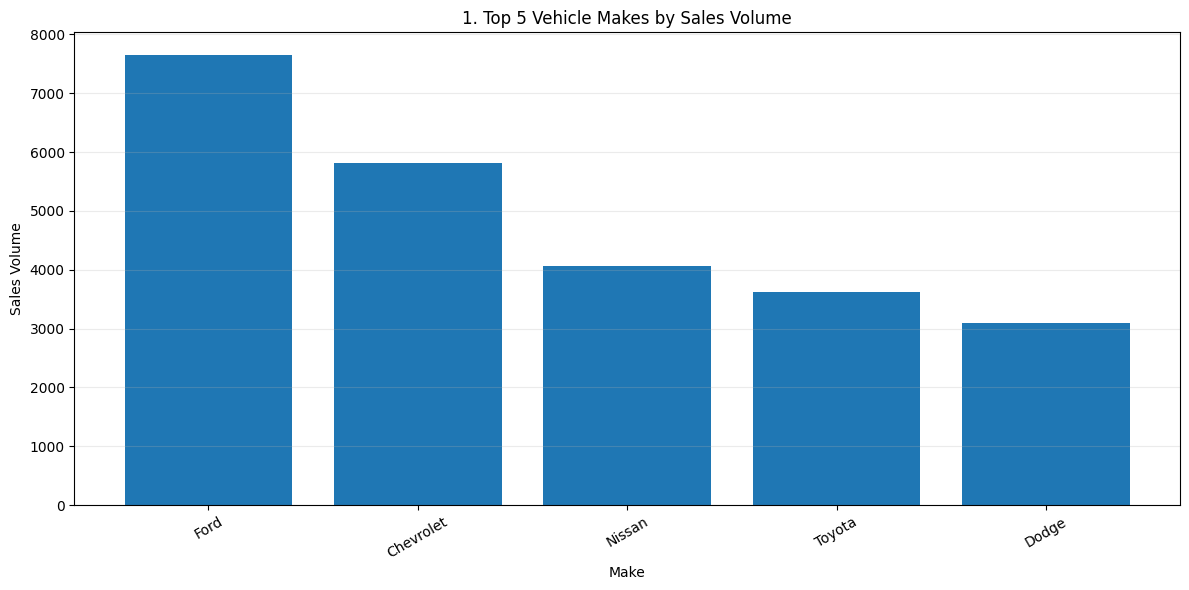

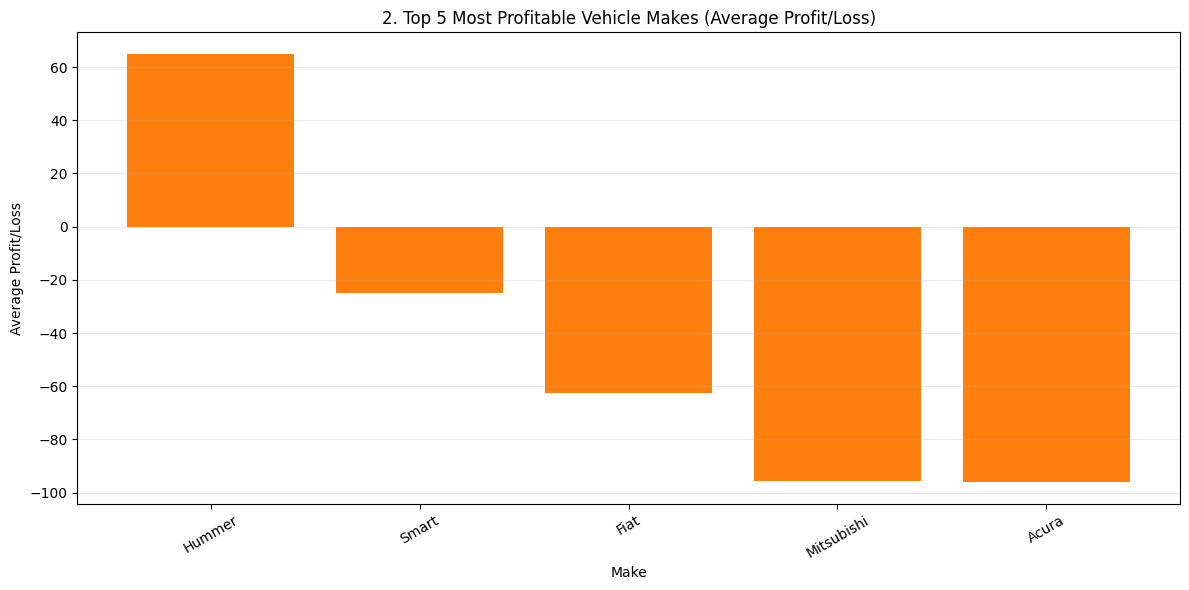

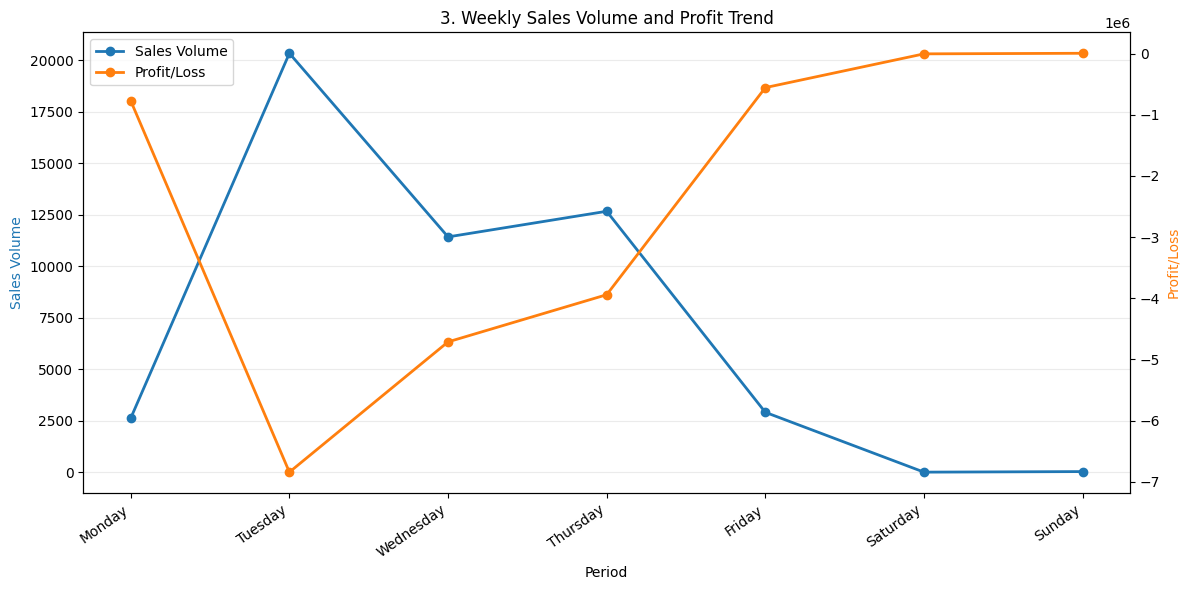

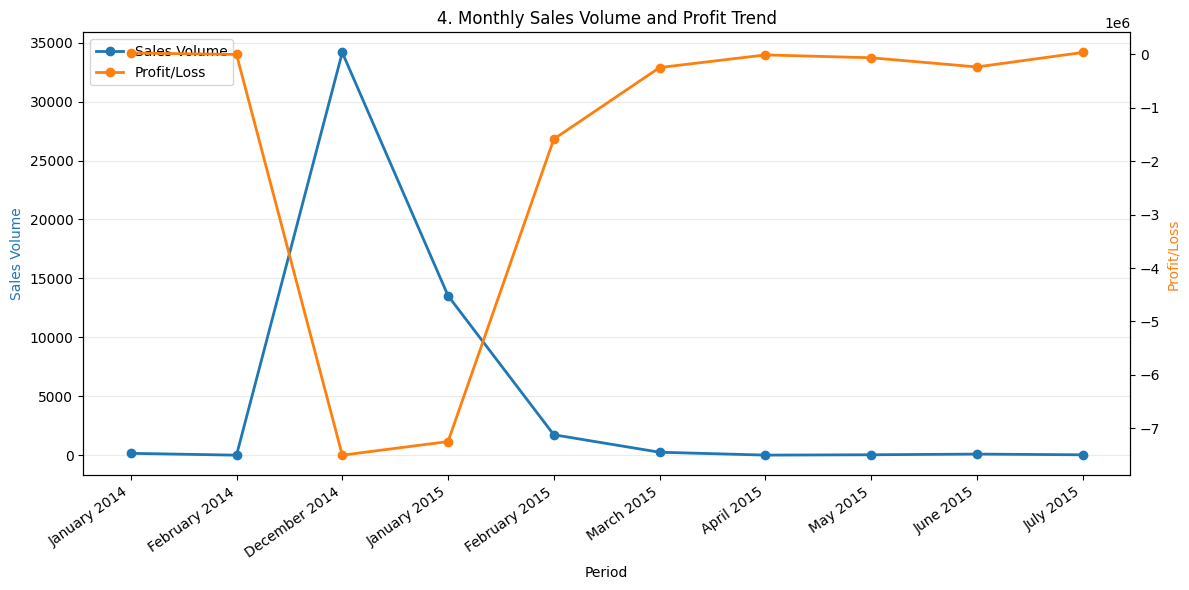

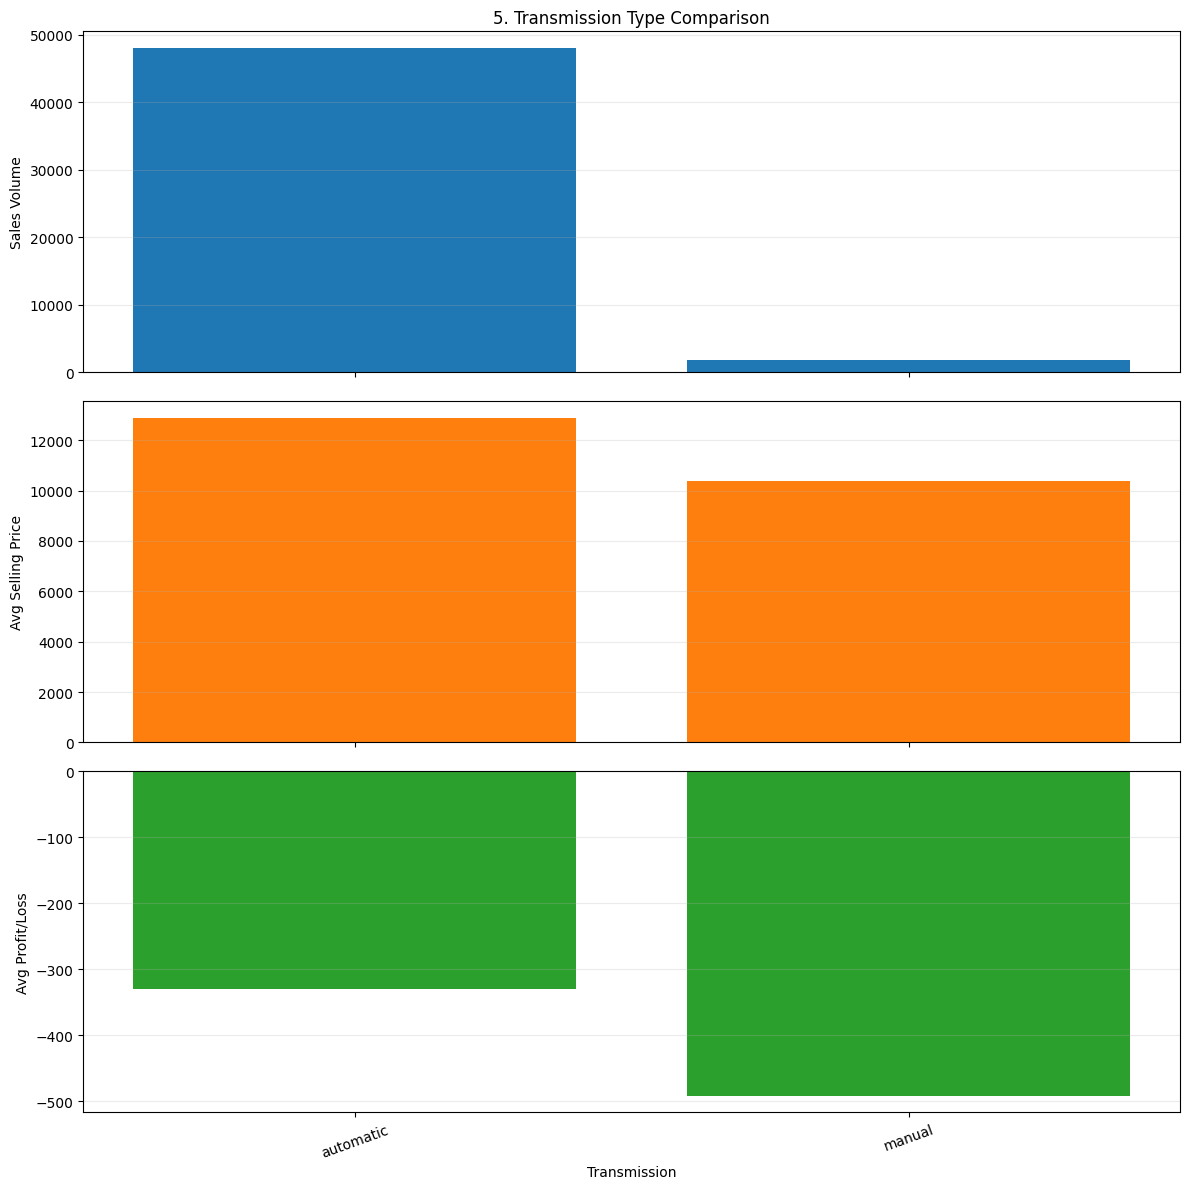

In [20]:
import matplotlib.pyplot as plt
from collections import defaultdict


def _fetch_rows(sql_query):
    conn = mysql.connector.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USER,
        password=DB_PASSWORD,
        database=DB_NAME
    )
    cursor = conn.cursor(dictionary=True)
    cursor.execute(sql_query)
    rows = cursor.fetchall()
    cursor.close()
    conn.close()
    return rows


def _bar_plot(title, labels, values, xlabel, ylabel, color="#2E86AB", rotation=30):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(labels, values, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotation)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def _dual_axis_plot(title, labels, left_name, left_values, right_name, right_values, left_ylabel, right_ylabel):
    fig, ax_left = plt.subplots(figsize=(12, 6))
    x_positions = list(range(len(labels)))
    ax_right = ax_left.twinx()

    left_line = ax_left.plot(x_positions, left_values, color="#1f77b4", marker="o", linewidth=2, label=left_name)
    right_line = ax_right.plot(x_positions, right_values, color="#ff7f0e", marker="o", linewidth=2, label=right_name)

    ax_left.set_title(title)
    ax_left.set_xlabel("Period")
    ax_left.set_ylabel(left_ylabel, color="#1f77b4")
    ax_right.set_ylabel(right_ylabel, color="#ff7f0e")
    ax_left.set_xticks(x_positions)
    ax_left.set_xticklabels(labels, rotation=35, ha="right")
    ax_left.grid(axis="y", alpha=0.25)

    handles = left_line + right_line
    labels_combined = [line.get_label() for line in handles]
    ax_left.legend(handles, labels_combined, loc="upper left")
    plt.tight_layout()
    plt.show()


def _multi_metric_transmission_plot(title, labels, sales_values, price_values, profit_values):
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    axes[0].bar(labels, sales_values, color="#1f77b4")
    axes[0].set_ylabel("Sales Volume")
    axes[0].set_title(title)
    axes[0].grid(axis="y", alpha=0.25)

    axes[1].bar(labels, price_values, color="#ff7f0e")
    axes[1].set_ylabel("Avg Selling Price")
    axes[1].grid(axis="y", alpha=0.25)

    axes[2].bar(labels, profit_values, color="#2ca02c")
    axes[2].set_ylabel("Avg Profit/Loss")
    axes[2].set_xlabel("Transmission")
    axes[2].grid(axis="y", alpha=0.25)

    for axis in axes:
        axis.tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()


def run_five_diagrams():
    try:
        # 1. Top 5 Vehicle Makes by Sales Volume
        make_rows = _fetch_rows("""
            SELECT make, COUNT(*) AS sales_volume
            FROM car_sales
            GROUP BY make
            ORDER BY sales_volume DESC
            LIMIT 5
        """)
        make_labels = [row["make"] for row in make_rows]
        make_values = [row["sales_volume"] for row in make_rows]
        _bar_plot(
            "1. Top 5 Vehicle Makes by Sales Volume",
            make_labels,
            make_values,
            "Make",
            "Sales Volume",
            color="#1f77b4"
        )

        # 2. Top 5 Most Profitable Vehicle Makes (Average Profit/Loss)
        profit_rows = _fetch_rows("""
            SELECT make, AVG(sellingprice - mmr) AS avg_profit_loss
            FROM car_sales
            GROUP BY make
            ORDER BY avg_profit_loss DESC
            LIMIT 5
        """)
        profit_labels = [row["make"] for row in profit_rows]
        profit_values = [row["avg_profit_loss"] for row in profit_rows]
        _bar_plot(
            "2. Top 5 Most Profitable Vehicle Makes (Average Profit/Loss)",
            profit_labels,
            profit_values,
            "Make",
            "Average Profit/Loss",
            color="#ff7f0e"
        )

        # 3. Weekly Sales Volume and Profit Trend
        weekly_rows = _fetch_rows("""
            SELECT
                saleday,
                COUNT(*) AS sales_volume,
                SUM(sellingprice - mmr) AS total_profit_loss
            FROM car_sales
            GROUP BY saleday, WEEKDAY(saledate)
            ORDER BY WEEKDAY(saledate) ASC
        """)
        weekly_labels = [row["saleday"] for row in weekly_rows]
        weekly_sales = [row["sales_volume"] for row in weekly_rows]
        weekly_profit = [row["total_profit_loss"] for row in weekly_rows]
        _dual_axis_plot(
            "3. Weekly Sales Volume and Profit Trend",
            weekly_labels,
            "Sales Volume",
            weekly_sales,
            "Profit/Loss",
            weekly_profit,
            "Sales Volume",
            "Profit/Loss"
        )

        # 4. Monthly Sales Volume and Profit Trend
        monthly_rows = _fetch_rows("""
            SELECT
                YEAR(saledate) AS sale_year,
                MONTH(saledate) AS sale_month_num,
                MONTHNAME(saledate) AS sale_month,
                COUNT(*) AS sales_volume,
                SUM(sellingprice - mmr) AS total_profit_loss
            FROM car_sales
            GROUP BY YEAR(saledate), MONTH(saledate), MONTHNAME(saledate)
            ORDER BY sale_year ASC, sale_month_num ASC
        """)
        monthly_labels = [f"{row['sale_month']} {row['sale_year']}" for row in monthly_rows]
        monthly_sales = [row["sales_volume"] for row in monthly_rows]
        monthly_profit = [row["total_profit_loss"] for row in monthly_rows]
        _dual_axis_plot(
            "4. Monthly Sales Volume and Profit Trend",
            monthly_labels,
            "Sales Volume",
            monthly_sales,
            "Profit/Loss",
            monthly_profit,
            "Sales Volume",
            "Profit/Loss"
        )

        # 5. Transmission Type Comparison
        transmission_rows = _fetch_rows("""
            SELECT
                transmission,
                COUNT(*) AS sales_volume,
                AVG(sellingprice) AS avg_selling_price,
                AVG(sellingprice - mmr) AS avg_profit_loss
            FROM car_sales
            GROUP BY transmission
        """)
        transmission_labels = [row["transmission"] for row in transmission_rows]
        transmission_sales = [row["sales_volume"] for row in transmission_rows]
        transmission_prices = [row["avg_selling_price"] for row in transmission_rows]
        transmission_profit = [row["avg_profit_loss"] for row in transmission_rows]
        _multi_metric_transmission_plot(
            "5. Transmission Type Comparison",
            transmission_labels,
            transmission_sales,
            transmission_prices,
            transmission_profit
        )

    except Error as e:
        print(f"[-] Diagram generation failed: {e}")


run_five_diagrams()